# Tabular Kaggle Project

## Melissa Tobias

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 2 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2252_data_3402_001-NLyiqHJ5btv8Y/Shared%20Documents/General/Kaggle%20Tabular%20Datasets.xlsx?d=w34cdd3378d1146a2ab63700189a8c5b5&csf=1&web=1&e=6ASD5s). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please go check with Dr. Farbin to make sure it is viable.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects.

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


- Link: https://www.kaggle.com/datasets/uciml/mushroom-classification?resource=download
- Challenge description: The goal is to classify mushrooms as either edible or poisonous based on their physical characteristics. Helps us explore classification techniques and understand how features like cap shape, color, and gill spacing can be predictive indicators.
- Describing the data: The dataset consists of categorical features that describe various observable traits of mushrooms. Each row represents a single mushroom specimen, and the target variable indicates whether it is edible or poisonous.

## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [1]:
#loading in dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df=pd.read_csv('mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [2]:
#counting rows and features

print(f"Number of rows: {df.shape[0]}")
print(f"Number of features (including target): {df.shape[1]}")

Number of rows: 8124
Number of features (including target): 23


In [3]:
# missing values, which are labeled as "?"

df.replace("?", pd.NA, inplace=True)
missing_values=df.isna().sum()
print("Missing values after replacing '?':\n", missing_values)

Missing values after replacing '?':
 class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64


In [4]:
feature_summary=[]

for col in df.columns:
    col_type="Categorical" if df[col].dtype=="object" else "Numerical"
    unique_vals=df[col].unique()
    num_missing=df[col].isna().sum()
    
    if col_type=="Categorical":
        value_range=", ".join(sorted(map(str, unique_vals)))[:50]+"..."
    else:
        value_range=f"{df[col].min()} to {df[col].max()}"
    
    feature_summary.append({
        "Feature": col,
        "Type": col_type,
        "Values": value_range,
        "Missing": num_missing
    })

summary_df=pd.DataFrame(feature_summary)
summary_df

,Feature,Type,Values,Missing
0,class,Categorical,"e, p...",0
1,cap-shape,Categorical,"b, c, f, k, s, x...",0
2,cap-surface,Categorical,"f, g, s, y...",0
3,cap-color,Categorical,"b, c, e, g, n, p, r, u, w, y...",0
4,bruises,Categorical,"f, t...",0
5,odor,Categorical,"a, c, f, l, m, n, p, s, y...",0
6,gill-attachment,Categorical,"a, f...",0
7,gill-spacing,Categorical,"c, w...",0
8,gill-size,Categorical,"b, n...",0
9,gill-color,Categorical,"b, e, g, h, k, n, o, p, r, u, w, y...",0


In [5]:
# dropping all rows that have any missing values

df.dropna(inplace=True)
print("Missing values after dropping:\n", df.isna().sum())

Missing values after dropping:
 class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


## Outlier definition:
* An observation that significantly deviates from other observations in the dataset.
For numerical features, this might be values far from the mean.
In this case, we might treat rare categories as potential anomalies.

In [6]:
#finding outliers, does not work traditionally since my dataset is purely categorical

#so we are finding rare categories
for col in df.columns:
    print(f"Feature: {col}")
    print(df[col].value_counts(normalize=True).tail())
    print()

Feature: class
class
e    0.618001
p    0.381999
Name: proportion, dtype: float64

Feature: cap-shape
cap-shape
f    0.430900
b    0.053154
k    0.006378
s    0.005670
c    0.000709
Name: proportion, dtype: float64

Feature: cap-surface
cap-surface
y    0.393338
f    0.382707
s    0.223246
g    0.000709
Name: proportion, dtype: float64

Feature: cap-color
cap-color
w    0.155918
e    0.104181
b    0.021262
p    0.017009
c    0.007796
Name: proportion, dtype: float64

Feature: bruises
bruises
t    0.564139
f    0.435861
Name: proportion, dtype: float64

Feature: odor
odor
a    0.070872
l    0.070872
p    0.045358
c    0.034018
m    0.006378
Name: proportion, dtype: float64

Feature: gill-attachment
gill-attachment
f    0.996811
a    0.003189
Name: proportion, dtype: float64

Feature: gill-spacing
gill-spacing
c    0.818568
w    0.181432
Name: proportion, dtype: float64

Feature: gill-size
gill-size
b    0.875266
n    0.124734
Name: proportion, dtype: float64

Feature: gill-color
gill-co

class
e    3488
p    2156
Name: count, dtype: int64


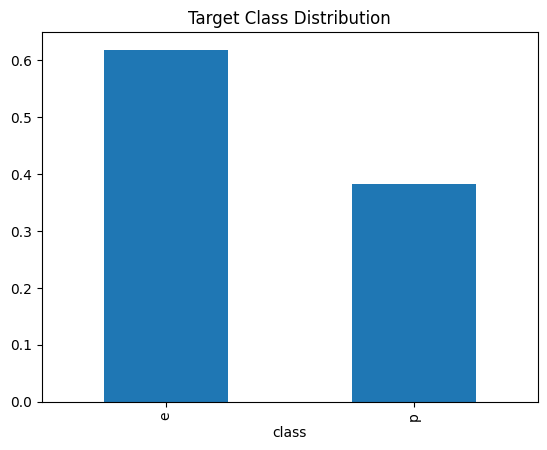

In [7]:
#class imbalance

df['class'].value_counts(normalize=True).plot(kind='bar', title='Target Class Distribution')
print(df['class'].value_counts())

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

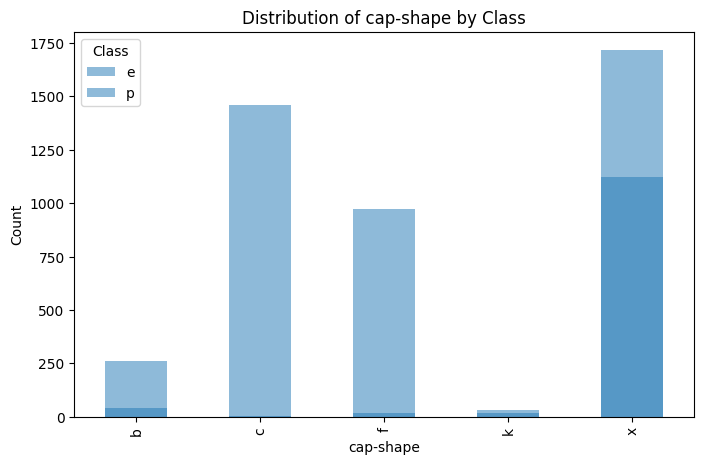

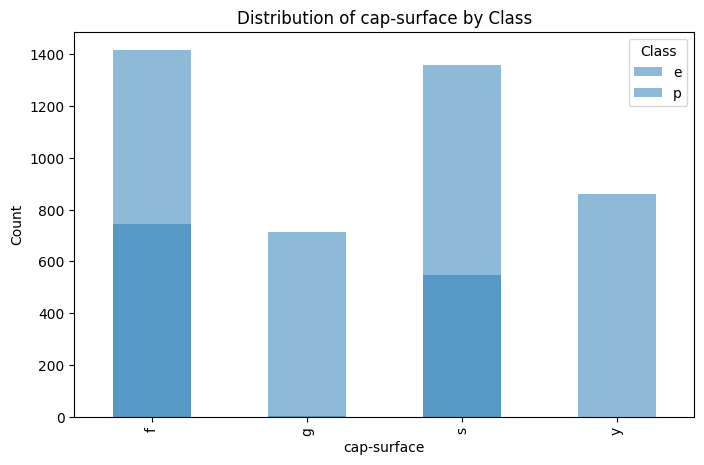

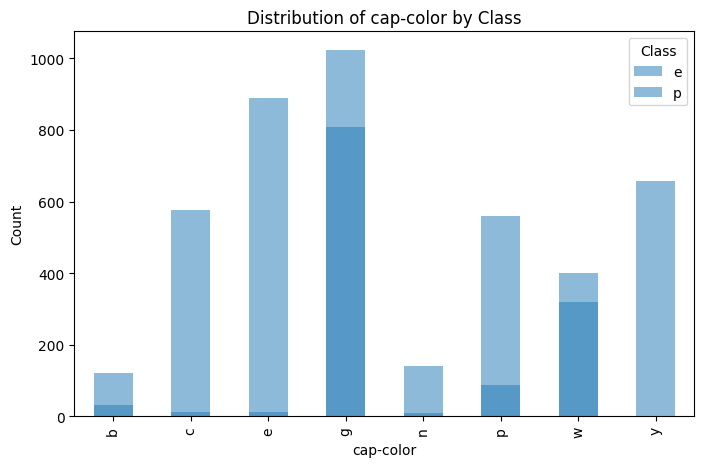

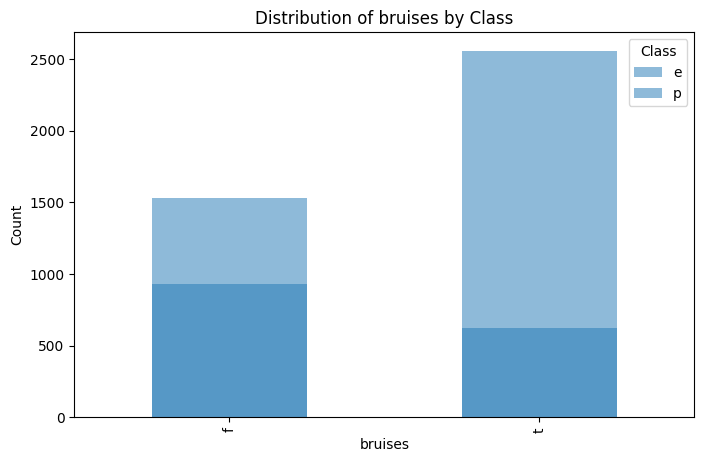

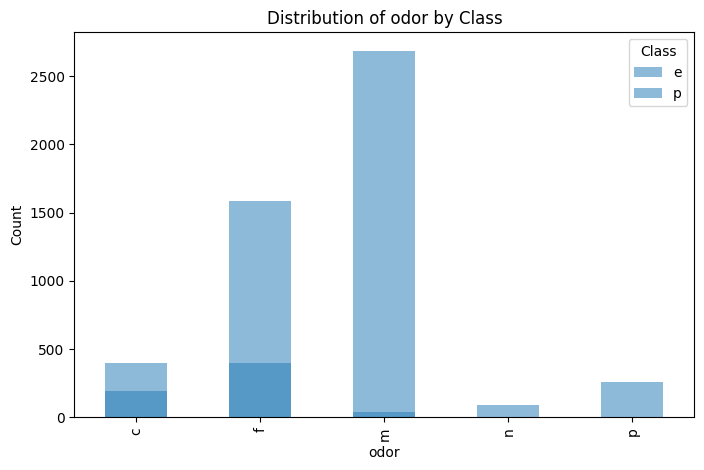

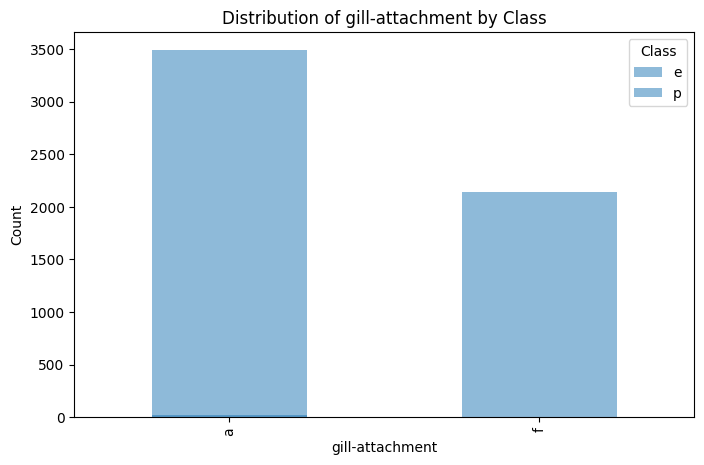

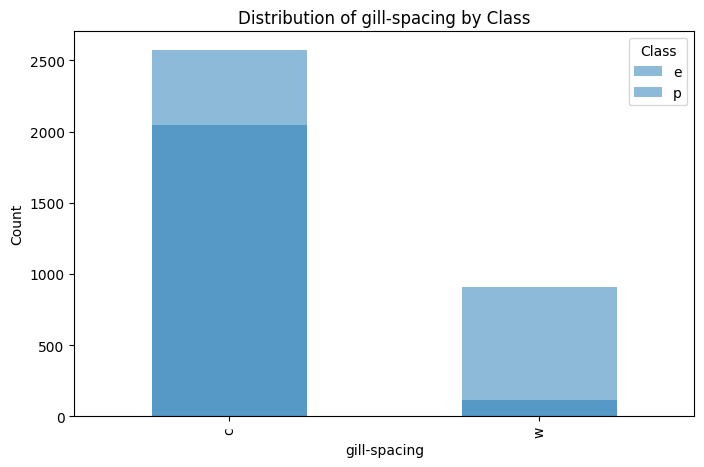

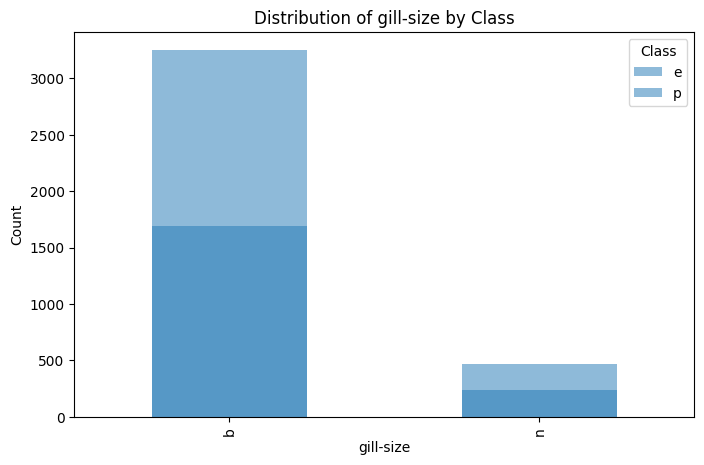

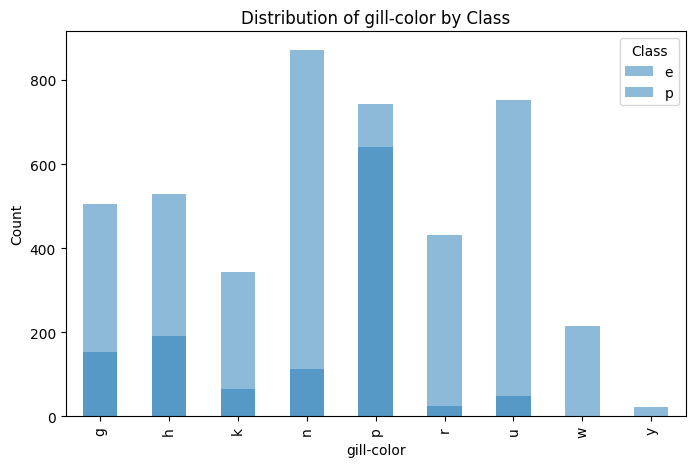

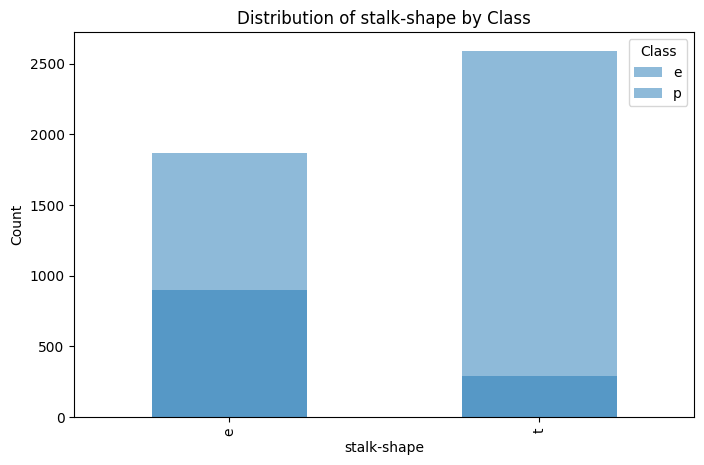

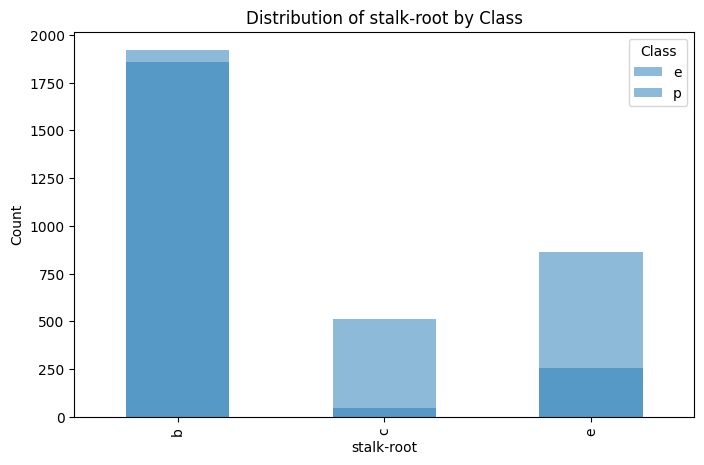

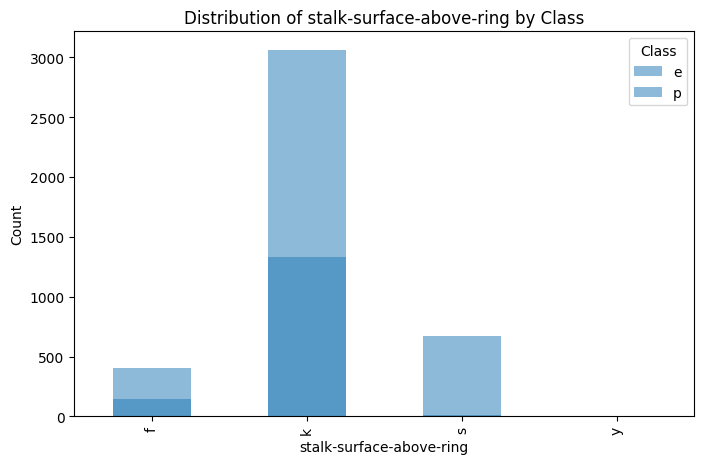

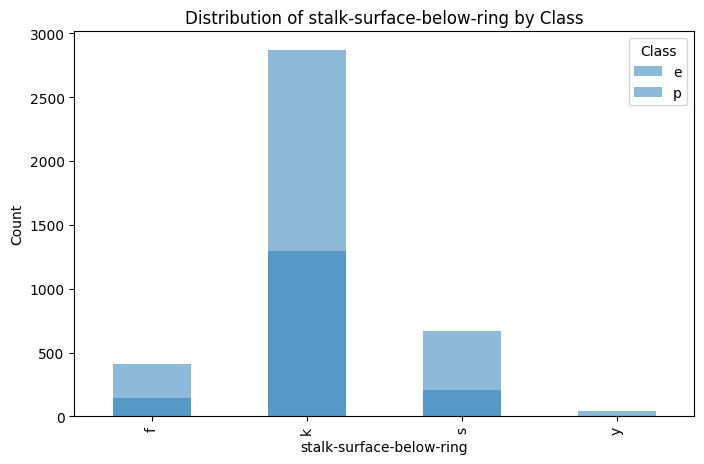

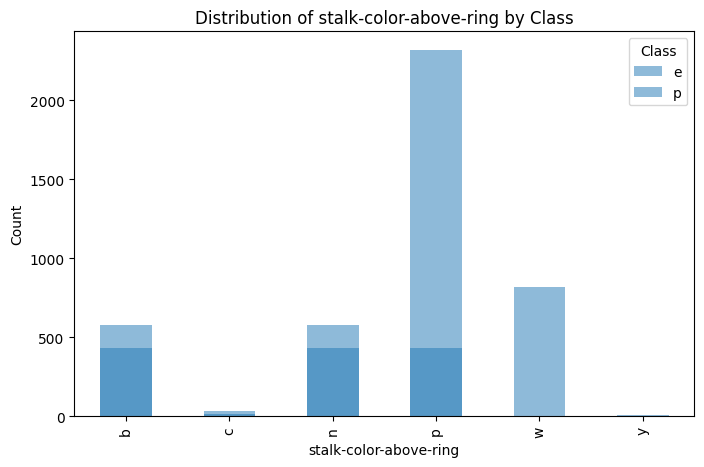

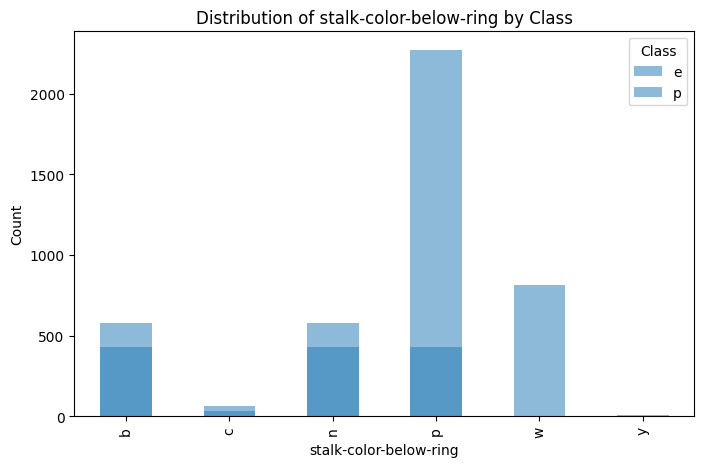

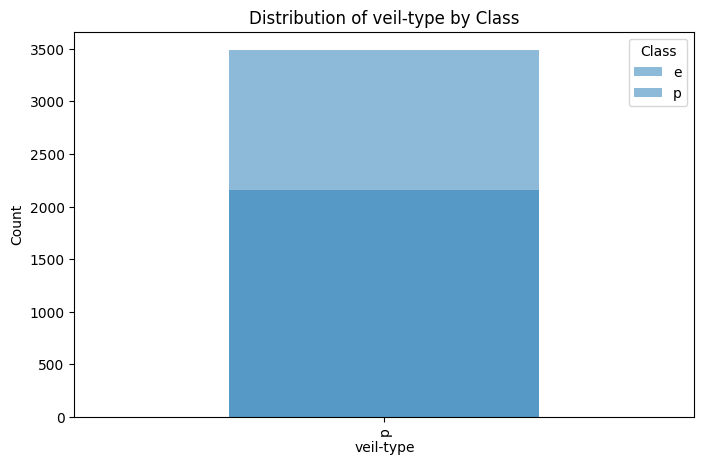

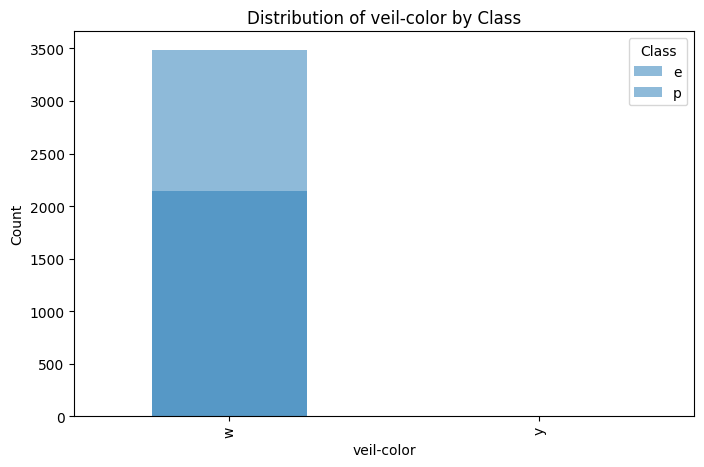

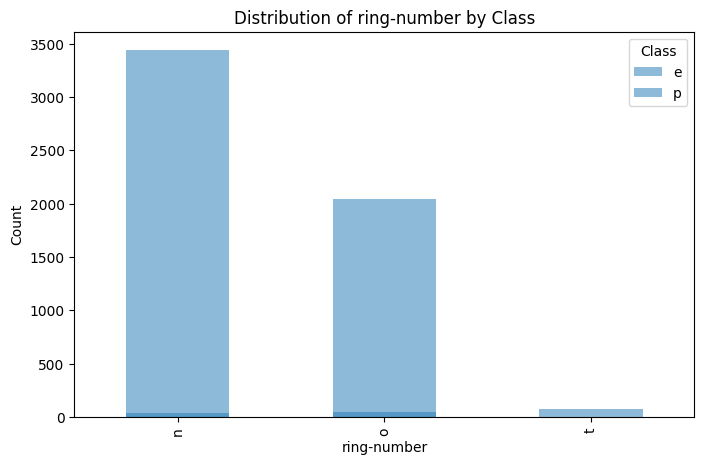

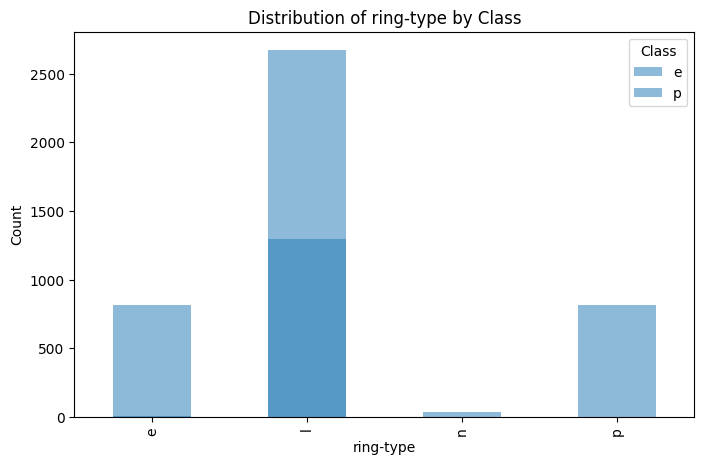

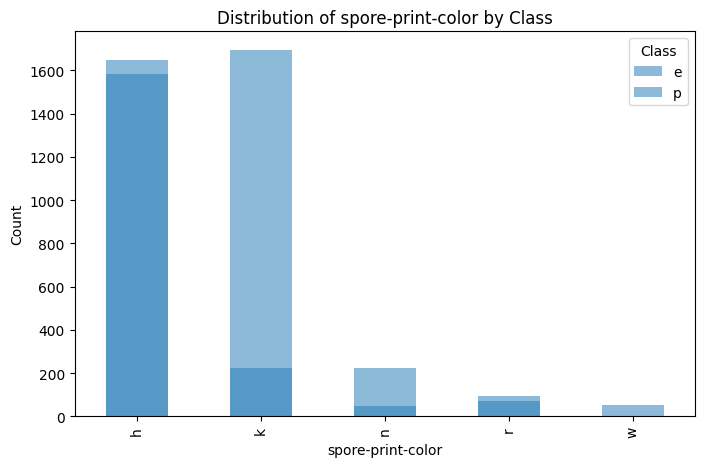

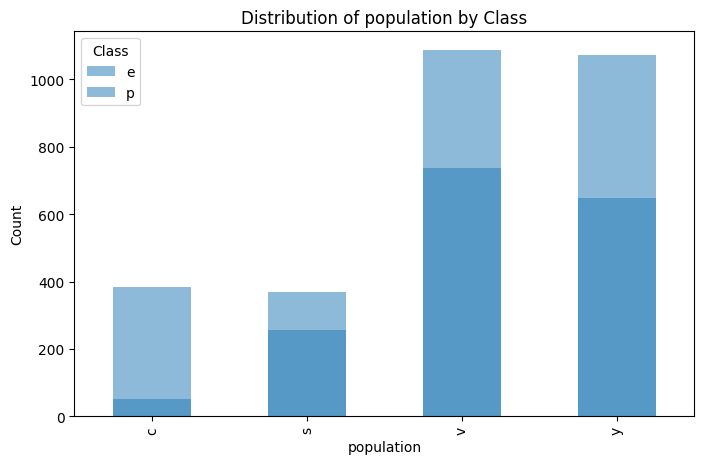

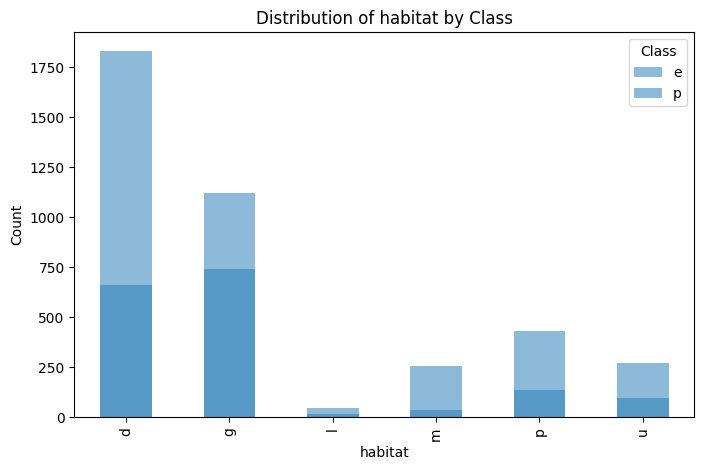

In [8]:
features = df.columns.drop('class')

for feature in features:
    fig, ax = plt.subplots(figsize=(8,5))
    for label in ['e', 'p']:
        subset = df[df['class'] == label]
        subset[feature].value_counts().sort_index().plot(kind='bar', alpha=0.5, label=label, ax=ax)
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(f'{feature}')
    plt.ylabel('Count')
    plt.legend(title='Class')
    plt.show()

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

In [9]:
# one-hot encode categorical features
X = pd.get_dummies(df.drop('class', axis=1))

# encoding target variable
y = df['class'].map({'e': 0, 'p': 1})

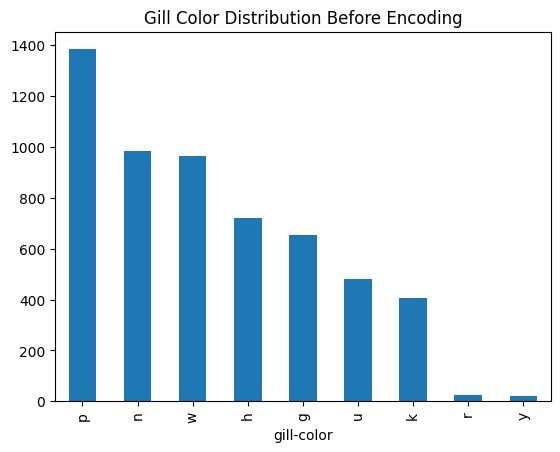

In [10]:
# visualize feature example before encoding
df['gill-color'].value_counts().plot(kind='bar')
plt.title('Gill Color Distribution Before Encoding')
plt.show()

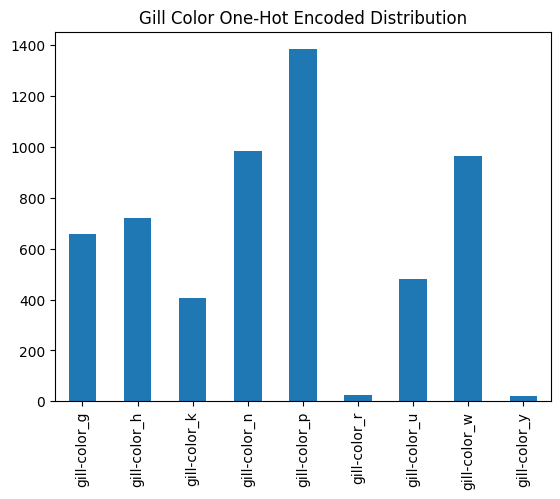

In [11]:
# visualize feature example after encoding
X.filter(like='gill-color').sum().plot(kind='bar')
plt.title('Gill Color One-Hot Encoded Distribution')
plt.show()

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


Validation Accuracy: 1.0000


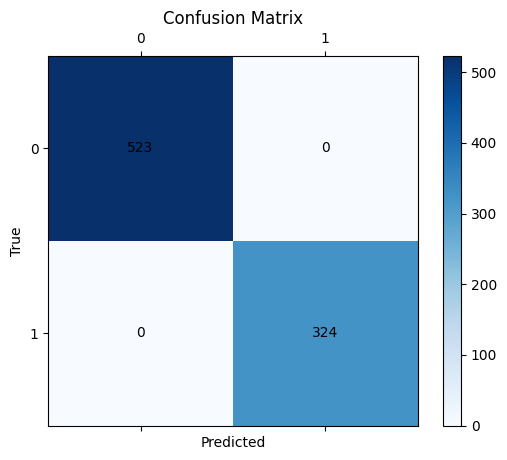


Confusion Matrix Table:
                Predicted Edible  Predicted Poisonous
True Edible                  523                    0
True Poisonous                 0                  324


In [12]:
# splitting data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# decision tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# validation predictions
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

# confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred)

# Plot confusion matrix
fig, ax = plt.subplots()
cax = ax.matshow(conf_matrix, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

for (i, j), val in np.ndenumerate(conf_matrix):
    ax.text(j, i, f'{val}', ha='center', va='center', color='black')

plt.colorbar(cax)
plt.show()

# results table
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['True Edible', 'True Poisonous'],
    columns=['Predicted Edible', 'Predicted Poisonous']
)

print("\nConfusion Matrix Table:")
print(conf_matrix_df)

# test predictions
y_test_pred = model.predict(X_test)